In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\lolla\Documents\Github(Remodified)\Titanic-Survival-Analysis\1.Data\titanic_data.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop('Cabin', axis=1, inplace=True)

In [6]:
print(df.shape)
print(df.info())
print(df.describe())

(891, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.1

In [7]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [8]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Pclass'], drop_first=True)

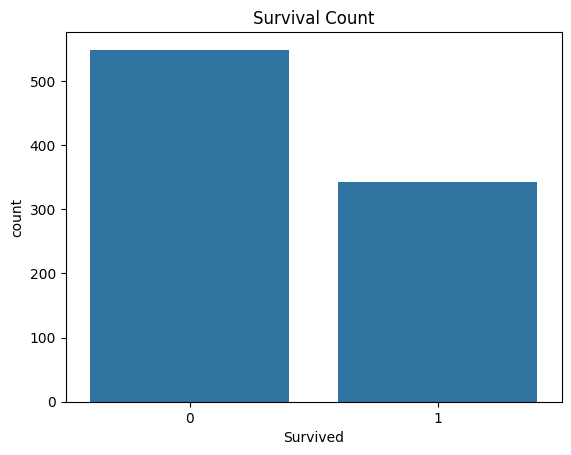

In [9]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

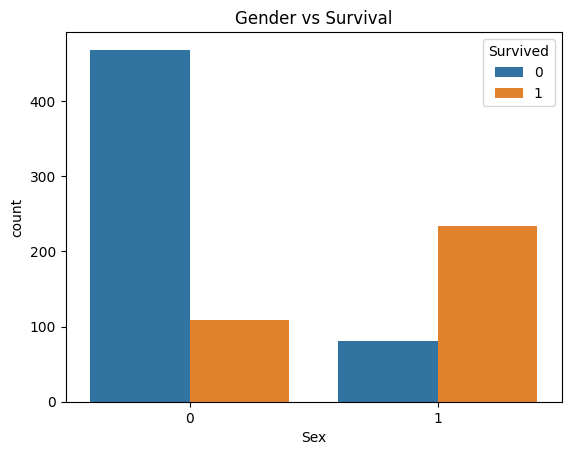

In [10]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

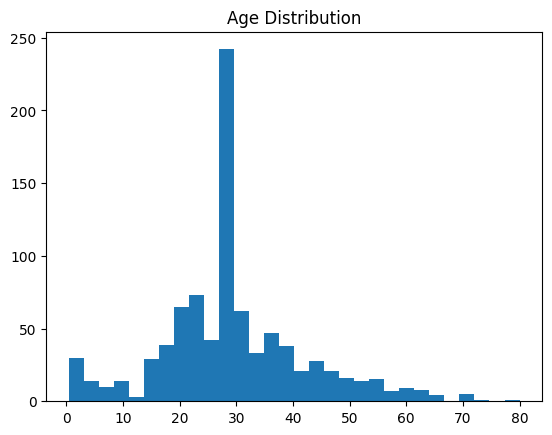

In [11]:
plt.hist(df['Age'], bins=30)
plt.title("Age Distribution")
plt.show()

In [12]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [13]:
print(df[['Sex']].head())

   Sex
0    0
1    1
2    1
3    1
4    0


In [14]:
print(df.columns)

Index(['Survived', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Pclass_2',
       'Pclass_3', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features = ['Sex', 'Age', 'SibSp', 'Parch', 'Fare',
            'Pclass_2', 'Pclass_3',
            'Embarked_Q', 'Embarked_S']

X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8044692737430168


c:\Users\lolla\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [17]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = 1
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [19]:
features = ['Sex', 'Age', 'Fare', 'SibSp', 'Parch',
            'FamilySize', 'IsAlone',
            'Pclass_2', 'Pclass_3',
            'Embarked_Q', 'Embarked_S']

X = df[features]
y = df['Survived']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#runned upto this

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,   # reduced for speed
    random_state=42,
    n_jobs=-1           # uses all CPU cores
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8212290502793296


In [24]:
from sklearn.metrics import classification_report

In [25]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



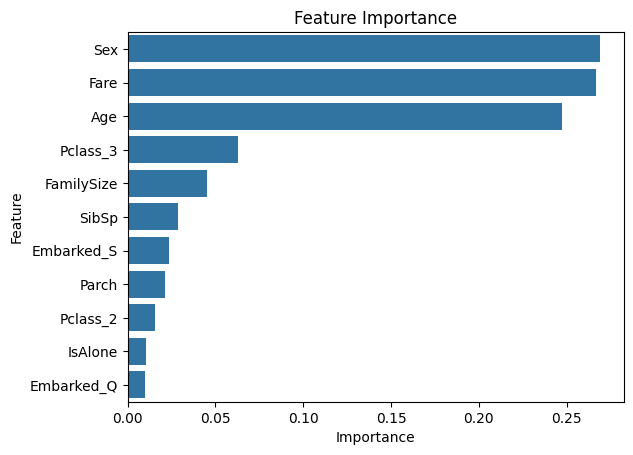

In [26]:
importances = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

feat_df = feat_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

In [31]:
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv(r"C:\Users\lolla\Documents\Github(Remodified)\Titanic-Survival-Analysis\1.Data\titanic_data.csv")

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})

features = ['Pclass','Sex','Age','Fare','FamilySize']

X = df[features]
y = df['Survived']

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X, y)
pickle.dump(model, open(r"C:\Users\lolla\Documents\Github(Remodified)\Titanic-Survival-Analysis\4.models\model.pkl", "wb"))

print("Model saved!")

C:\Users\lolla\AppData\Local\Temp\ipykernel_5040\1206343724.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\lolla\AppData\Local\Temp\ipykernel_5040\1206343724.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

Model saved!
